# Chapter 15: Nonlinearity and Lookup Functions

*Systems Thinking with AI* by Jason Karpeles

A lookup shows where its evidence ends; a fitted formula keeps answering after it has none.

**Goal.** Four demonstrations built from the chapter's six saturation observations. Compare a lookup with a fit inside the data, watch the fit answer a question the data cannot, turn monotonic and bounded into checks, and swap the shape of a relationship while keeping its endpoints.

**Demonstrations**

1. Inside the data, a lookup and a fit agree
2. Outside the data, the fit answers and the lookup refuses
3. Monotonic and bounded are claims, so test them
4. Does the conclusion survive a change of shape?

The chapter's own model code is written out in full below, so the notebook runs with NumPy and Matplotlib alone. The interactive version of this chapter is at [https://karpeles.com/companions/systems-thinking-with-ai/15-lookups/reader.html](https://karpeles.com/companions/systems-thinking-with-ai/15-lookups/reader.html).

All example inputs are constructed teaching examples built from the chapter's own numbers.

## Setup

Imports, plus two small helpers: `%%module` runs a cell as a named module so the chapter files can import one another by their package names, and `show` draws a demonstration's figure and lists its values.

In [1]:
import os, sys, tempfile, types
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from IPython.core.magic import register_cell_magic
from IPython.display import Markdown, display

%matplotlib inline

WORKDIR = tempfile.mkdtemp(prefix="systems-thinking-")


@register_cell_magic
def module(line, cell):
    """Run a cell as a named module so the chapter code can import it by name."""
    name = line.strip()
    parts = name.split(".")
    for i in range(1, len(parts)):
        parent = ".".join(parts[:i])
        if parent not in sys.modules:
            pkg = types.ModuleType(parent)
            pkg.__path__ = []
            sys.modules[parent] = pkg
            if i > 1:
                setattr(sys.modules[".".join(parts[:i - 1])], parts[i - 1], pkg)
    mod = types.ModuleType(name)
    mod.__file__ = os.path.join(WORKDIR, *parts) + ".py"
    mod.__package__ = ".".join(parts[:-1])
    sys.modules[name] = mod
    if len(parts) > 1:
        setattr(sys.modules[".".join(parts[:-1])], parts[-1], mod)
    exec(compile(cell, name, "exec"), mod.__dict__)


def show(result):
    """Draw the figure, then list the calculated values and the reading."""
    fig, metrics, interpretation = result[:3]
    plt.show()
    display(Markdown("\n".join(f"- **{k}:** {v}" for k, v in metrics.items())))
    display(Markdown(interpretation))


def sweep(function, controls):
    """Recompute every setting offered in the interactive reader and list the values."""
    import itertools
    keys = [k for k, _ in controls]
    rows = []
    for combo in itertools.product(*[v for _, v in controls]):
        fig, metrics, _ = function(**dict(zip(keys, combo)))[:3]
        plt.close(fig)
        setting = ", ".join(f"{k} = {v}" for k, v in zip(keys, combo))
        rows.append(f"- **{setting}**: " + "; ".join(f"{k} {v}" for k, v in metrics.items()))
    display(Markdown("\n".join(rows)))


## The chapter's model code

Each cell below is one file of the chapter's code, defined under its package name. Later chapters build on earlier ones, so some files come from the chapters they cite.

`chapters/chapter_15_lookups/code/lookup.py`

In [2]:
%%module chapters.chapter_15_lookups.code.lookup
"""A lookup that interpolates inside its evidence and refuses outside it."""

from bisect import bisect_left


class OutsideDomain(ValueError):
    """Raised when a lookup is asked about a region no observation covers."""


class Lookup:
    """Piecewise-linear interpolation over observed points, with a closed domain."""

    def __init__(self, points: list[tuple[float, float]], name: str = "lookup") -> None:
        if len(points) < 2:
            raise ValueError("a lookup needs at least two observed points")
        ordered = sorted(points)
        xs = [x for x, _ in ordered]
        if len(set(xs)) != len(xs):
            raise ValueError("a lookup cannot hold two values for the same input")
        self.name = name
        self.xs = xs
        self.ys = [y for _, y in ordered]

    @property
    def domain(self) -> tuple[float, float]:
        return self.xs[0], self.xs[-1]

    def __call__(self, x: float) -> float:
        low, high = self.domain
        # A solver that lands on a domain end arrives a few machine epsilons past
        # it. Refusing that is refusing arithmetic, not refusing extrapolation, so
        # an input within a hair of an end is snapped to it and anything further
        # out is still refused.
        tolerance = 1e-9 * max(1.0, abs(low), abs(high))
        if low - tolerance <= x < low:
            x = low
        elif high < x <= high + tolerance:
            x = high
        if not low <= x <= high:
            raise OutsideDomain(
                f"{self.name} was asked about {x}, outside its observed domain [{low}, {high}]"
            )
        i = bisect_left(self.xs, x)
        if self.xs[i] == x:
            return self.ys[i]
        x0, x1, y0, y1 = self.xs[i - 1], self.xs[i], self.ys[i - 1], self.ys[i]
        return y0 + (y1 - y0) * (x - x0) / (x1 - x0)

    def is_monotonic(self) -> bool:
        """True when the relationship never reverses direction."""
        up = all(b >= a for a, b in zip(self.ys, self.ys[1:], strict=False))
        down = all(b <= a for a, b in zip(self.ys, self.ys[1:], strict=False))
        return up or down

    def is_bounded_by(self, low: float, high: float) -> bool:
        return all(low <= y <= high for y in self.ys)


def fit_polynomial(points: list[tuple[float, float]], degree: int) -> list[float]:
    """Least-squares polynomial coefficients, lowest order first. Deliberately naive."""
    n = degree + 1
    if len(points) < n:
        raise ValueError("not enough points for that degree")
    xs = [x for x, _ in points]
    ys = [y for _, y in points]
    a = [[sum(x ** (i + j) for x in xs) for j in range(n)] for i in range(n)]
    b = [sum(y * x**i for x, y in zip(xs, ys, strict=True)) for i in range(n)]
    for col in range(n):
        pivot = max(range(col, n), key=lambda r: abs(a[r][col]))
        if abs(a[pivot][col]) < 1e-12:
            raise ValueError("the fit is singular at this degree")
        a[col], a[pivot] = a[pivot], a[col]
        b[col], b[pivot] = b[pivot], b[col]
        for r in range(n):
            if r == col:
                continue
            factor = a[r][col] / a[col][col]
            a[r] = [x - factor * y for x, y in zip(a[r], a[col], strict=True)]
            b[r] -= factor * b[col]
    return [b[i] / a[i][i] for i in range(n)]


def evaluate_polynomial(coefficients: list[float], x: float) -> float:
    """A fit will answer any question asked of it. That is the problem."""
    return sum(c * x**i for i, c in enumerate(coefficients))


Formatting and plotting helpers used by the demonstrations (`readerkit`).

In [3]:
%%module readerkit
"""Formatting and plotting helpers shared by the demonstrations."""
from __future__ import annotations

import math

# Restrained palette with good contrast on white. Use direct labels, not
# colour alone, to distinguish series.
PALETTE = {
    "ink": "#172a3b",
    "teal": "#136f75",
    "gold": "#8f5d0f",
    "navy": "#334c72",
    "terracotta": "#a24a33",
    "olive": "#5d6a37",
    "grey": "#6b757b",
    "light": "#c9d3d6",
}

FONT_SIZE = 11.5
SMALL_FONT = 10.5


def new_figure(ncols=1, width=None, height=4.3):
    """Return (fig, axes) with constrained layout and the house size.

    One panel is 6.6 x 4.3 inches; two panels are 10.4 x 4.3 inches. At the
    reader's display width this keeps 11 to 12 point text legible.
    """
    import matplotlib.pyplot as plt

    if width is None:
        width = 6.6 if ncols == 1 else 10.4
    fig, axes = plt.subplots(1, ncols, figsize=(width, height), layout="constrained")
    for ax in (axes if ncols > 1 else [axes]):
        ax.grid(alpha=0.18)
    return fig, axes


def fmt(value, digits=2):
    """Format a finite number with a fixed number of decimals.

    Returns the string "undefined" for None. Raises ValueError for NaN or
    infinity, because a reader must be told why a value is undefined; use
    ``undefined(reason)`` for that.
    """
    if value is None:
        return "undefined"
    value = float(value)
    if not math.isfinite(value):
        raise ValueError("non-finite value; state why it is undefined with undefined(reason)")
    text = f"{value:.{digits}f}"
    if text.startswith("-") and float(text) == 0:
        text = text[1:]
    return text


def signed(value, digits=2):
    """Format a number for use inside a written calculation: negatives get parentheses."""
    text = fmt(value, digits)
    return f"({text})" if text.startswith("-") else text


def undefined(reason):
    """Display string for a quantity that has no value in this state."""
    return f"undefined ({reason})"


def is_tie(a, b, tol=1e-9):
    return abs(float(a) - float(b)) <= tol


def argmax_set(scores, tol=1e-9):
    """Names whose score is within tol of the maximum. ``scores`` is a dict."""
    best = max(scores.values())
    return [name for name, value in scores.items() if abs(value - best) <= tol]


def label_point(ax, x, y, text, color=None, dx=6, dy=6, ha="left", va="bottom", size=None):
    """Directly label a point with an offset in points (no arrow)."""
    return ax.annotate(
        text,
        (x, y),
        xytext=(dx, dy),
        textcoords="offset points",
        ha=ha,
        va=va,
        color=color or PALETTE["ink"],
        fontsize=size or SMALL_FONT,
    )


## Demonstration functions

Each function below runs the chapter's model for one demonstration and returns a figure, the calculated values and a worked reading of them.

In [4]:
"""Chapter 15 reader: a lookup that refuses, a fit that answers anything.

Every lookup and fit value comes from the Chapter 15 pack (Lookup, fit_polynomial,
evaluate_polynomial). The six observed points are the chapter's saturation example.
"""
from __future__ import annotations

import numpy as np
from readerkit import PALETTE, fmt, label_point, new_figure, signed

from chapters.chapter_15_lookups.code.lookup import (
    Lookup,
    OutsideDomain,
    evaluate_polynomial,
    fit_polynomial,
)

EQ_LOOKUP_25 = "saturation(2.5)"
EQ_FIT_25 = "evaluate_polynomial(fit_polynomial(points, 5), 2.5)"
EQ_FIT_12 = "evaluate_polynomial(fit_polynomial(points, 5), 12.0)"
EQ_MONO = "saturation.is_monotonic()"
EQ_BOUND = "saturation.is_bounded_by(0.0, 1.0)"
EQ_BUILD = 'saturation = Lookup(points, "saturation")'

POINTS = [(0, 0), (1, 0.35), (2, 0.6), (3, 0.78), (4, 0.88), (5, 0.93)]


def _segment_text(lookup, x):
    """Hand calculation of a piecewise-linear reading, with the numbers of this state."""
    for xi, yi in zip(lookup.xs, lookup.ys):
        if xi == x:
            return f"{fmt(x, 1)} is an observed point, so the reading is its own value {fmt(yi, 2)}"
    i = next(k for k, xi in enumerate(lookup.xs) if xi > x)
    x0, x1, y0, y1 = lookup.xs[i - 1], lookup.xs[i], lookup.ys[i - 1], lookup.ys[i]
    value = y0 + (y1 - y0) * (x - x0) / (x1 - x0)
    return (f"{fmt(y0, 2)} + ({fmt(y1, 2)} - {fmt(y0, 2)}) x ({fmt(x, 1)} - {fmt(x0, 1)})"
            f"/({fmt(x1, 1)} - {fmt(x0, 1)}) = {fmt(value, 3)}")


# Demonstration 1: inside the data a lookup and a fit agree.

def inside_the_data(load=2.5, degree=5):
    saturation = Lookup(POINTS, "saturation")
    coefficients = fit_polynomial(POINTS, degree)
    look = saturation(load)
    fit = evaluate_polynomial(coefficients, load)
    grid = np.linspace(0, 5, 101)

    fig, ax = new_figure()
    ax.plot(grid, [saturation(g) for g in grid], color=PALETTE["navy"], linewidth=2)
    ax.plot(grid, [evaluate_polynomial(coefficients, g) for g in grid], color=PALETTE["terracotta"],
            linestyle="dashed", linewidth=2)
    ax.scatter([p[0] for p in POINTS], [p[1] for p in POINTS], color=PALETTE["ink"], zorder=3)
    ax.axvline(load, color=PALETTE["grey"], linewidth=1.2)
    ax.scatter([load, load], [look, fit], color=[PALETTE["navy"], PALETTE["terracotta"]], s=60, zorder=4)
    label_point(ax, 0.1, 0.8, "Lookup (solid)", color=PALETTE["navy"], dx=0, dy=0)
    label_point(ax, 0.1, 0.7, f"Degree {degree} fit (dashed)", color=PALETTE["terracotta"], dx=0, dy=0)
    ax.set_xlim(-0.2, 5.3)
    ax.set_ylim(-0.1, 1.05)
    ax.set_xlabel("Load")
    ax.set_ylabel("Effectiveness (fraction)")

    look_shown, fit_shown = round(look, 3), round(fit, 3)
    gap = fit_shown - look_shown
    metrics = {
        "Lookup reading": fmt(look, 3),
        "Fit reading": fmt(fit, 3),
        "Fit minus lookup": signed(gap, 3),
    }
    interpretation = (
        f"At a load of {fmt(load, 1)} the lookup reads {_segment_text(saturation, load)}. The degree {degree} "
        f"fit reads {fmt(fit, 3)}. Fit minus lookup = {fmt(fit_shown, 3)} - {fmt(look_shown, 3)} = "
        f"{signed(gap, 3)}. Inside the six observations the two are close, so on this evidence alone "
        f"there is no reason to prefer one."
    )
    alt = (f"The lookup and a degree {degree} fit drawn over loads 0 to 5 through the six observed points, "
           f"with a vertical line at load {fmt(load, 1)} where they read {fmt(look, 3)} and {fmt(fit, 3)}.")
    return fig, metrics, interpretation, alt


# Demonstration 2: outside the data the lookup refuses and the fit answers.

def outside_the_data(asked=12.0, degree=5):
    saturation = Lookup(POINTS, "saturation")
    coefficients = fit_polynomial(POINTS, degree)
    fit = evaluate_polynomial(coefficients, asked)
    try:
        look = saturation(asked)
        refusal = None
    except OutsideDomain:
        look = None
        refusal = "refuses (OutsideDomain)"
    top = 2.4
    bottom = -1.4
    grid = np.linspace(0, 12, 241)
    curve = np.clip([evaluate_polynomial(coefficients, g) for g in grid], bottom, top)

    fig, ax = new_figure()
    ax.axhspan(0, 1, color=PALETTE["light"], alpha=0.45)
    ax.plot(np.linspace(0, 5, 101), [saturation(g) for g in np.linspace(0, 5, 101)], color=PALETTE["navy"], linewidth=2.4)
    ax.plot(grid, curve, color=PALETTE["terracotta"], linestyle="dashed", linewidth=1.8)
    ax.axvline(5, color=PALETTE["grey"], linewidth=1.2)
    shown = min(max(fit, bottom), top)
    ax.scatter([asked], [shown], color=PALETTE["terracotta"], s=60, zorder=4)
    where = "right" if asked > 8 else "left"
    label_point(ax, asked, shown, f"Fit: {fmt(fit, 2)}", color=PALETTE["terracotta"],
                dx=-8 if where == "right" else 8, dy=-20 if look is None else -24, ha=where)
    if look is not None:
        ax.scatter([asked], [look], color=PALETTE["navy"], s=60, zorder=4)
        label_point(ax, asked, look, f"Lookup: {fmt(look, 2)}", color=PALETTE["navy"], dx=-8, dy=12, ha="right")
    else:
        label_point(ax, 5.2, 1.7, "Lookup refuses beyond load 5", color=PALETTE["navy"], dx=0, dy=0)
    label_point(ax, 12.2, 1.0, "Allowed range 0 to 1 (shaded)", color=PALETTE["grey"], dx=0, dy=6, ha="right")
    ax.set_xlim(0, 12.3)
    ax.set_ylim(bottom, top)
    ax.set_xlabel("Load asked about (the fit is clipped at the frame)")
    ax.set_ylabel("Effectiveness (fraction)")

    if fit > 1:
        verdict = f"{fmt(fit, 2)} - 1.00 = {fmt(round(fit, 2) - 1, 2)} above the largest value a fraction can take"
    elif fit < 0:
        verdict = f"{fmt(fit, 2)} - 0.00 = {signed(fit, 2)}, below the smallest value a fraction can take"
    else:
        verdict = f"{fmt(fit, 2)} lies between 0.00 and 1.00, so this particular reading happens to look plausible"
    metrics = {
        "Load asked": fmt(asked, 1),
        "Lookup": fmt(look, 2) if look is not None else refusal,
        "Fit": fmt(fit, 2),
        "Fit within 0 to 1": "yes" if 0 <= fit <= 1 else "no",
    }
    if look is None:
        head = (f"The observed domain is 0 to 5 and {fmt(asked, 1)} - 5.0 = {fmt(asked - 5, 1)} lies beyond its end, "
                f"so the lookup refuses and names the missing evidence.")
    else:
        head = (f"Load {fmt(asked, 1)} - 5.0 = {fmt(asked - 5, 1)} beyond the last observation, so it is the edge of the domain: "
                f"the lookup reads its own value {fmt(look, 2)}, which is not extrapolation.")
    interpretation = (
        f"{head} The degree {degree} fit answers anyway: {verdict}. The fit carries no flag that it has left the data."
    )
    alt = (f"The lookup curve ends at load 5 while the degree {degree} fit continues dashed to load 12; "
           f"at load {fmt(asked, 1)} the fit reads {fmt(fit, 2)} against an allowed range of 0 to 1.")
    return fig, metrics, interpretation, alt


# Demonstration 3: monotonic and bounded are claims that tests can hold.

def claims_as_tests(second_value=0.6, last_value=0.93):
    points = [(0, 0), (1, 0.35), (2, second_value), (3, 0.78), (4, 0.88), (5, last_value)]
    lookup = Lookup(points, "saturation")
    ys = lookup.ys
    steps = [b - a for a, b in zip(ys, ys[1:])]
    direct_mono = all(s >= 0 for s in steps)
    direct_bound = max(ys) <= 1.0 and min(ys) >= 0.0
    assert lookup.is_monotonic() == direct_mono
    assert lookup.is_bounded_by(0.0, 1.0) == direct_bound
    flat = any(abs(s) < 1e-12 for s in steps[1:])

    fig, ax = new_figure()
    ax.axhline(1.0, color=PALETTE["grey"], linestyle="dashed", linewidth=1.3)
    ax.plot(lookup.xs, ys, color=PALETTE["navy"], linewidth=2, marker="o")
    for i, s in enumerate(steps):
        if s < 0:
            ax.plot(lookup.xs[i:i + 2], ys[i:i + 2], color=PALETTE["terracotta"], linewidth=3.5)
    label_point(ax, 0.1, 1.0, "Ceiling of 1.0", color=PALETTE["grey"], dx=0, dy=4)
    for x, y in zip(lookup.xs, ys):
        ax.annotate(fmt(y, 2), (x, y), xytext=(0, -16), textcoords="offset points", ha="center",
                    fontsize=10.5, color=PALETTE["ink"])
    ax.set_xlim(-0.3, 5.3)
    ax.set_ylim(-0.12, 1.2)
    ax.set_xlabel("Load")
    ax.set_ylabel("Effectiveness (fraction)")

    steps_text = ", ".join(signed(s, 2) for s in steps)
    mono_text = "True" if direct_mono else "False"
    bound_text = "True" if direct_bound else "False"
    reversal = [i for i, s in enumerate(steps) if s < 0]
    where = (f" The step from load {lookup.xs[reversal[0]]} to load {lookup.xs[reversal[0] + 1]} is negative, "
             f"which is a reversal.") if reversal else ""
    tie_note = " A flat step of 0.00 is not a reversal, so a tie stays monotonic." if flat and direct_mono else ""
    interpretation = (
        f"Step changes between neighbouring points are {steps_text}.{where}{tie_note} Monotonic = {mono_text}. "
        f"Largest value {fmt(max(ys), 2)} against the ceiling 1.00: {fmt(max(ys), 2)} - 1.00 = "
        f"{signed(max(ys) - 1.0, 2)}, so bounded between 0 and 1 = {bound_text}."
    )
    metrics = {
        "Monotonic": mono_text,
        "Bounded between 0 and 1": bound_text,
        "Smallest step": signed(min(steps), 2),
        "Largest value": fmt(max(ys), 2),
    }
    alt = (f"A lookup through six points; the value at load 2 is {fmt(second_value, 2)} and at load 5 is "
           f"{fmt(last_value, 2)}. Monotonic is {mono_text} and bounded is {bound_text}.")
    return fig, metrics, interpretation, alt


# Demonstration 4: three shapes through the same ends.

SHAPES = {
    "line": [(0, 0), (5, 0.93)],
    "curve": POINTS,
    "threshold": [(0, 0), (2, 0.05), (3, 0.1), (3.5, 0.9), (5, 0.93)],
}
SHAPE_NAMES = {"line": "Straight line", "curve": "Gentle curve", "threshold": "Sharp threshold"}
REQUIRED = 0.6


def shape_test(shape="curve", load=3.0):
    lookups = {k: Lookup(v, k) for k, v in SHAPES.items()}
    reading = lookups[shape](load)
    verdicts = {k: lookups[k](load) >= REQUIRED for k in lookups}
    agree = len(set(verdicts.values())) == 1
    grid = np.linspace(0, 5, 101)

    fig, ax = new_figure()
    colors = {"line": PALETTE["grey"], "curve": PALETTE["navy"], "threshold": PALETTE["terracotta"]}
    for k, lk in lookups.items():
        ax.plot(grid, [lk(g) for g in grid], color=colors[k], linewidth=3.2 if k == shape else 1.3,
                alpha=1.0 if k == shape else 0.7)
    ax.axhline(REQUIRED, color=PALETTE["gold"], linestyle="dotted", linewidth=1.6)
    ax.axvline(load, color=PALETTE["ink"], linewidth=1.0)
    ax.scatter([load], [reading], color=colors[shape], s=70, zorder=4)
    label_point(ax, 0.1, REQUIRED, "Required 0.60", color=PALETTE["gold"], dx=0, dy=4)
    label_point(ax, 0.1, 1.02, "Line (grey), curve (blue), threshold (red)", color=PALETTE["ink"], dx=0, dy=0, va="top")
    ax.set_xlim(0, 5.1)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel("Load")
    ax.set_ylabel("Effectiveness (fraction)")

    meets = verdicts[shape]
    count = sum(verdicts.values())
    metrics = {
        "Shape chosen": SHAPE_NAMES[shape],
        "Reading at this load": fmt(reading, 3),
        "Meets 0.60": "yes" if meets else "no",
        "Shapes that meet 0.60": f"{count} of 3",
        "Do the three shapes agree": "yes" if agree else "no",
    }
    others = ", ".join(f"{SHAPE_NAMES[k].lower()} {fmt(lookups[k](load), 3)}" for k in lookups)
    tail = ("The conclusion holds across all three shapes, so the shape is not load-bearing here."
            if agree else "The conclusion flips between shapes, so it is a finding about the shape, and the shape needs evidence.")
    interpretation = (
        f"Chosen shape, {SHAPE_NAMES[shape].lower()}, at load {fmt(load, 1)}: {_segment_text(lookups[shape], load)}. "
        f"Against the requirement, {fmt(reading, 3)} - {fmt(REQUIRED, 2)} = {signed(round(reading, 3) - REQUIRED, 3)}, "
        f"so it {'meets' if meets else 'misses'} 0.60. All three readings: {others}. {count} of 3 meet it. {tail}"
    )
    alt = (f"Three curves through the same first and last points: a straight line, a gentle curve and a sharp "
           f"threshold. The {SHAPE_NAMES[shape].lower()} is bold and reads {fmt(reading, 3)} at load {fmt(load, 1)}.")
    return fig, metrics, interpretation, alt


## 1. Inside the data, a lookup and a fit agree

*Where the evidence exists, does it matter whether the bend is held as a table or a formula?*

The lookup interpolates between the two neighbouring observations. A degree 5 polynomial passes through all six points, so between them it stays near the same curve. A low degree cannot pass through every point and drifts a little further from the table.

    saturation(2.5)
    evaluate_polynomial(fit_polynomial(points, 5), 2.5)

**Symbols and inputs.** Load is the input, from 0 to 5. Effectiveness is a fraction. The six observed points are (0, 0), (1, 0.35), (2, 0.6), (3, 0.78), (4, 0.88) and (5, 0.93). The lookup draws straight lines between them; the fit is a least-squares polynomial of the chosen degree.

**Predict first.** At a load of 2.5, will the degree 5 fit and the lookup differ by more than 0.05?

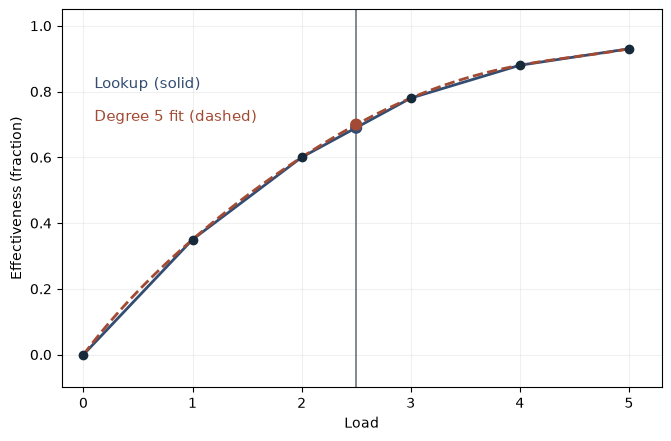

- **Lookup reading:** 0.690
- **Fit reading:** 0.699
- **Fit minus lookup:** 0.009

At a load of 2.5 the lookup reads 0.60 + (0.78 - 0.60) x (2.5 - 2.0)/(3.0 - 2.0) = 0.690. The degree 5 fit reads 0.699. Fit minus lookup = 0.699 - 0.690 = 0.009. Inside the six observations the two are close, so on this evidence alone there is no reason to prefer one.

In [5]:
show(inside_the_data(load=2.5, degree=5))

**Use the idea.** When two representations agree inside the evidence, choose between them on what happens outside it.

**Where the conclusion applies.** Six constructed observations treated as exact. Agreement here says nothing about loads above 5, and a fit of low degree can disagree with the table even inside the data.

*Constructed example: the chapter's six saturation points, read with the chapter's Lookup and fit_polynomial.*

Every setting the interactive reader offers for this demonstration:

In [6]:
sweep(inside_the_data, [('load', [1.5, 2.5, 3.5, 4.5]), ('degree', [2, 5])])

- **load = 1.5, degree = 2**: Lookup reading 0.475; Fit reading 0.478; Fit minus lookup 0.003
- **load = 1.5, degree = 5**: Lookup reading 0.475; Fit reading 0.484; Fit minus lookup 0.009
- **load = 2.5, degree = 2**: Lookup reading 0.690; Fit reading 0.699; Fit minus lookup 0.009
- **load = 2.5, degree = 5**: Lookup reading 0.690; Fit reading 0.699; Fit minus lookup 0.009
- **load = 3.5, degree = 2**: Lookup reading 0.830; Fit reading 0.845; Fit minus lookup 0.015
- **load = 3.5, degree = 5**: Lookup reading 0.830; Fit reading 0.840; Fit minus lookup 0.010
- **load = 4.5, degree = 2**: Lookup reading 0.905; Fit reading 0.916; Fit minus lookup 0.011
- **load = 4.5, degree = 5**: Lookup reading 0.905; Fit reading 0.906; Fit minus lookup 0.001

## 2. Outside the data, the fit answers and the lookup refuses

*What do the two representations say about a load nobody observed?*

Past the last observation the highest order term of the polynomial takes over, so the answer is set by the functional form and not by the data. The lookup has nothing to interpolate from, so it raises OutsideDomain.

    evaluate_polynomial(fit_polynomial(points, 5), 12.0)
    saturation(2.5)

**Symbols and inputs.** Load asked is the input. The lookup's observed domain is 0 to 5. The effectiveness is a fraction, so any honest value lies between 0 and 1.

**Predict first.** At a load of 12 with the degree 5 fit, is the fit's answer inside 0 to 1?

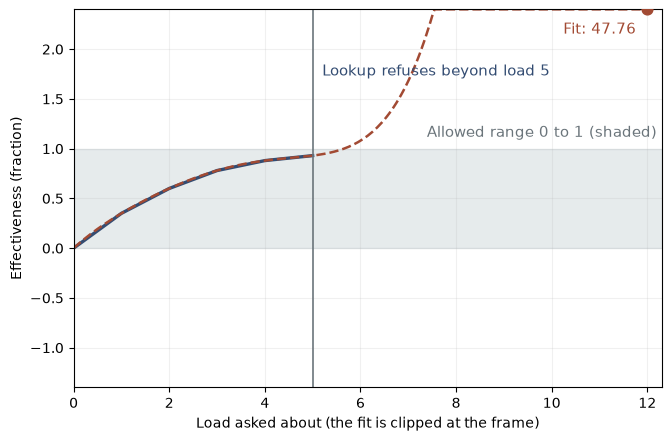

- **Load asked:** 12.0
- **Lookup:** refuses (OutsideDomain)
- **Fit:** 47.76
- **Fit within 0 to 1:** no

The observed domain is 0 to 5 and 12.0 - 5.0 = 7.0 lies beyond its end, so the lookup refuses and names the missing evidence. The degree 5 fit answers anyway: 47.76 - 1.00 = 46.76 above the largest value a fraction can take. The fit carries no flag that it has left the data.

In [7]:
show(outside_the_data(asked=12.0, degree=5))

**Use the idea.** Treat the refusal as information: it turns an invisible extrapolation into a decision to get an observation, state an assumption, or restrict the operating range.

**Where the conclusion applies.** Effectiveness is a fraction bounded by 0 and 1. A lower degree can look plausible at some loads and still be unsupported there; the failure is that it is silent, not that it is always large.

*Constructed example: the chapter's saturation points; the load 12 value 47.76 is the chapter's own printed result.*

Every setting the interactive reader offers for this demonstration:

In [8]:
sweep(outside_the_data, [('asked', [5.0, 6.0, 8.0, 12.0]), ('degree', [3, 5])])

- **asked = 5.0, degree = 3**: Load asked 5.0; Lookup 0.93; Fit 0.93; Fit within 0 to 1 yes
- **asked = 5.0, degree = 5**: Load asked 5.0; Lookup 0.93; Fit 0.93; Fit within 0 to 1 yes
- **asked = 6.0, degree = 3**: Load asked 6.0; Lookup refuses (OutsideDomain); Fit 0.93; Fit within 0 to 1 yes
- **asked = 6.0, degree = 5**: Load asked 6.0; Lookup refuses (OutsideDomain); Fit 1.08; Fit within 0 to 1 no
- **asked = 8.0, degree = 3**: Load asked 8.0; Lookup refuses (OutsideDomain); Fit 0.86; Fit within 0 to 1 yes
- **asked = 8.0, degree = 5**: Load asked 8.0; Lookup refuses (OutsideDomain); Fit 3.36; Fit within 0 to 1 no
- **asked = 12.0, degree = 3**: Load asked 12.0; Lookup refuses (OutsideDomain); Fit 0.71; Fit within 0 to 1 yes
- **asked = 12.0, degree = 5**: Load asked 12.0; Lookup refuses (OutsideDomain); Fit 47.76; Fit within 0 to 1 no

## 3. Monotonic and bounded are claims, so test them

*How does a lookup fail the two checks the chapter asks it to pass?*

Interpolation does not guarantee either property. A noisy point can introduce a wiggle, and a value above 1.0 breaks the ceiling of a fraction. Writing both as tests makes a later edit that introduces them fail loudly.

    saturation.is_monotonic()
    saturation.is_bounded_by(0.0, 1.0)
    saturation = Lookup(points, "saturation")

**Symbols and inputs.** The lookup holds six points. Monotonic means no step between neighbouring points is negative. Bounded means every value lies from 0.0 to 1.0. The two controls change the observation at load 2 and at load 5.

**Predict first.** If the value at load 5 falls to 0.85 while load 4 stays at 0.88, does the monotonic check pass?

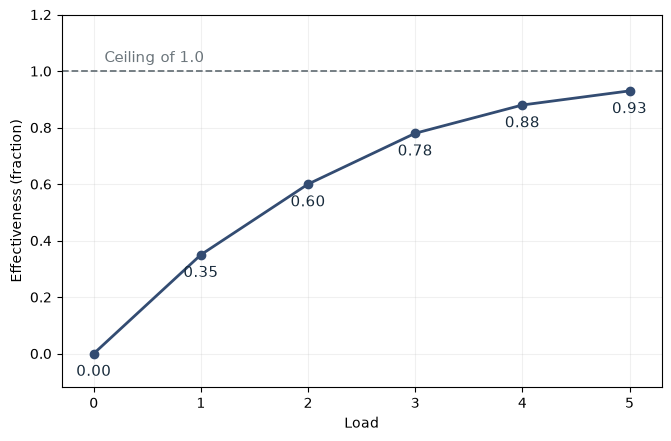

- **Monotonic:** True
- **Bounded between 0 and 1:** True
- **Smallest step:** 0.05
- **Largest value:** 0.93

Step changes between neighbouring points are 0.35, 0.25, 0.18, 0.10, 0.05. Monotonic = True. Largest value 0.93 against the ceiling 1.00: 0.93 - 1.00 = (-0.07), so bounded between 0 and 1 = True.

In [9]:
show(claims_as_tests(second_value=0.6, last_value=0.93))

**Use the idea.** Keep these assertions beside the lookup so a later edit cannot add a wiggle unnoticed.

**Where the conclusion applies.** A flat step counts as monotonic because the relationship never falls. Whether it should be strictly rising is a domain decision the check does not make.

*Constructed example: the chapter's six points with two values changed for this reader to trigger each failure.*

Every setting the interactive reader offers for this demonstration:

In [10]:
sweep(claims_as_tests, [('second_value', [0.6, 0.8]), ('last_value', [0.85, 0.88, 0.93, 1.04])])

- **second_value = 0.6, last_value = 0.85**: Monotonic False; Bounded between 0 and 1 True; Smallest step (-0.03); Largest value 0.88
- **second_value = 0.6, last_value = 0.88**: Monotonic True; Bounded between 0 and 1 True; Smallest step 0.00; Largest value 0.88
- **second_value = 0.6, last_value = 0.93**: Monotonic True; Bounded between 0 and 1 True; Smallest step 0.05; Largest value 0.93
- **second_value = 0.6, last_value = 1.04**: Monotonic True; Bounded between 0 and 1 False; Smallest step 0.10; Largest value 1.04
- **second_value = 0.8, last_value = 0.85**: Monotonic False; Bounded between 0 and 1 True; Smallest step (-0.03); Largest value 0.88
- **second_value = 0.8, last_value = 0.88**: Monotonic False; Bounded between 0 and 1 True; Smallest step (-0.02); Largest value 0.88
- **second_value = 0.8, last_value = 0.93**: Monotonic False; Bounded between 0 and 1 True; Smallest step (-0.02); Largest value 0.93
- **second_value = 0.8, last_value = 1.04**: Monotonic False; Bounded between 0 and 1 False; Smallest step (-0.02); Largest value 1.04

## 4. Does the conclusion survive a change of shape?

*If a line, a curve and a threshold pass through the same ends, do they lead to the same conclusion?*

Away from the shared ends the shapes differ most. Near load 3 a threshold is still low and the curve is already high, so the conclusion can flip. Near load 4 all three have risen enough to agree.

    saturation = Lookup(points, "saturation")
    saturation(2.5)

**Symbols and inputs.** Three relationships share the points (0, 0) and (5, 0.93). The requirement is an effectiveness of 0.60. The control picks the shape and the load at which the conclusion is read.

**Predict first.** At a load of 3, do all three shapes meet the 0.60 requirement?

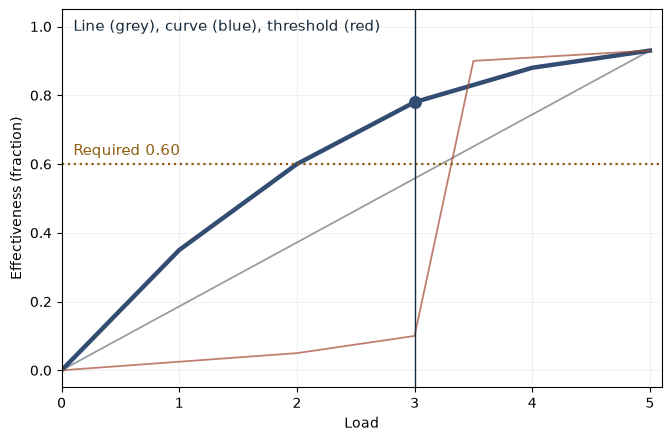

- **Shape chosen:** Gentle curve
- **Reading at this load:** 0.780
- **Meets 0.60:** yes
- **Shapes that meet 0.60:** 1 of 3
- **Do the three shapes agree:** no

Chosen shape, gentle curve, at load 3.0: 3.0 is an observed point, so the reading is its own value 0.78. Against the requirement, 0.780 - 0.60 = 0.180, so it meets 0.60. All three readings: straight line 0.558, gentle curve 0.780, sharp threshold 0.100. 1 of 3 meet it. The conclusion flips between shapes, so it is a finding about the shape, and the shape needs evidence.

In [11]:
show(shape_test(shape='curve', load=3.0))

**Use the idea.** Before trusting a finding, redraw the lookup as a line, a gentle curve and a threshold and rerun; if the finding flips, collect evidence for the shape.

**Where the conclusion applies.** Three hand-drawn shapes, one operating load at a time and one requirement. A conclusion can also depend on the endpoints, which this test holds fixed.

*Constructed example: the chapter's curve plus two alternative shapes defined for this reader, all read with the chapter's Lookup.*

Every setting the interactive reader offers for this demonstration:

In [12]:
sweep(shape_test, [('shape', ['line', 'curve', 'threshold']), ('load', [3.0, 4.0])])

- **shape = line, load = 3.0**: Shape chosen Straight line; Reading at this load 0.558; Meets 0.60 no; Shapes that meet 0.60 1 of 3; Do the three shapes agree no
- **shape = line, load = 4.0**: Shape chosen Straight line; Reading at this load 0.744; Meets 0.60 yes; Shapes that meet 0.60 3 of 3; Do the three shapes agree yes
- **shape = curve, load = 3.0**: Shape chosen Gentle curve; Reading at this load 0.780; Meets 0.60 yes; Shapes that meet 0.60 1 of 3; Do the three shapes agree no
- **shape = curve, load = 4.0**: Shape chosen Gentle curve; Reading at this load 0.880; Meets 0.60 yes; Shapes that meet 0.60 3 of 3; Do the three shapes agree yes
- **shape = threshold, load = 3.0**: Shape chosen Sharp threshold; Reading at this load 0.100; Meets 0.60 no; Shapes that meet 0.60 1 of 3; Do the three shapes agree no
- **shape = threshold, load = 4.0**: Shape chosen Sharp threshold; Reading at this load 0.910; Meets 0.60 yes; Shapes that meet 0.60 3 of 3; Do the three shapes agree yes

## Exercises

Try each before opening the answer. The settings above let you check the numbers.

### Exercise 1

At a load of 1.5, what does the lookup read, using the points at loads 1 and 2?

<details><summary>Answer</summary>

0.35 + (0.6 - 0.35) x (1.5 - 1)/(2 - 1) = 0.35 + 0.125 = 0.475.

</details>

### Exercise 2

If a degree 5 fit returns 47.76 for a fraction, how far above its ceiling is that?

<details><summary>Answer</summary>

47.76 - 1.00 = 46.76 above the largest value a fraction can take.

</details>

### Exercise 3

If the value at load 5 is 0.88 and load 4 is 0.88, is the lookup still monotonic?

<details><summary>Answer</summary>

The step is 0.88 - 0.88 = 0.00, which is not negative, so yes: a flat step is a tie, not a reversal.

</details>

---

From *Systems Thinking with AI* by Jason Karpeles. Copyright Jason Karpeles. All rights reserved.

Interactive companion: https://karpeles.com/companions/systems-thinking-with-ai/